In [2]:
!pip install ucimlrepo pandas numpy matplotlib scikit-learn

In [3]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-lea

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

In [5]:
dataset = fetch_ucirepo(id=572)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

df = X.copy()
df["Bankrupt?"] = y

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [6]:
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["Bankrupt?"].value_counts())

print("\nTarget distribution (%):")
print(df["Bankrupt?"].value_counts(normalize=True) * 100)

print("\nSummary statistics:")
print(df.describe())

print("\nInfinite values:")
print(np.isinf(df.select_dtypes(include=[np.number])).sum().sum())

print("\nNon-numeric columns:")
print(df.drop(columns=["Bankrupt?"]).select_dtypes(exclude=[np.number]).columns.tolist())

Shape: (6819, 96)

First 5 rows:
    ROA(C) before interest and depreciation before interest  \
0                                           0.370594          
1                                           0.464291          
2                                           0.426071          
3                                           0.399844          
4                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                           0.472295    
3                                           0.457733    
4                         

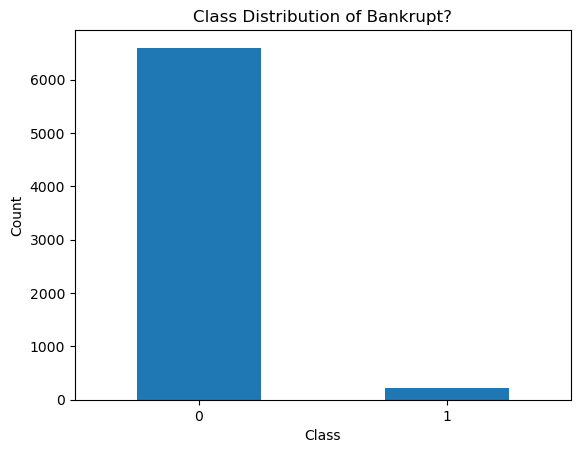

In [7]:
df["Bankrupt?"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Bankrupt?")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Bankrupt?"])
y = df["Bankrupt?"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())

X_train shape: (5455, 95)
X_test shape: (1364, 95)
y_train distribution:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64
y_test distribution:
Bankrupt?
0    1320
1      44
Name: count, dtype: int64


In [9]:
from imblearn.over_sampling import SMOTE
import pandas as pd

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64

After SMOTE:
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)
y_pred = rf_smote.predict(X_test)

In [11]:
y_pred = rf_smote.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average="weighted", zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average="weighted", zero_division=0))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9611436950146628
Precision: 0.9681226214735307
Recall: 0.9611436950146628
F1-score: 0.9641632890658263
Balanced Accuracy: 0.7821969696969697

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.43      0.59      0.50        44

    accuracy                           0.96      1364
   macro avg       0.71      0.78      0.74      1364
weighted avg       0.97      0.96      0.96      1364



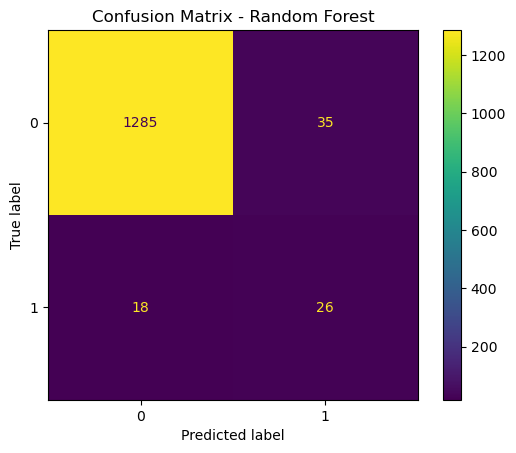

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

ROC-AUC Score: 0.9450


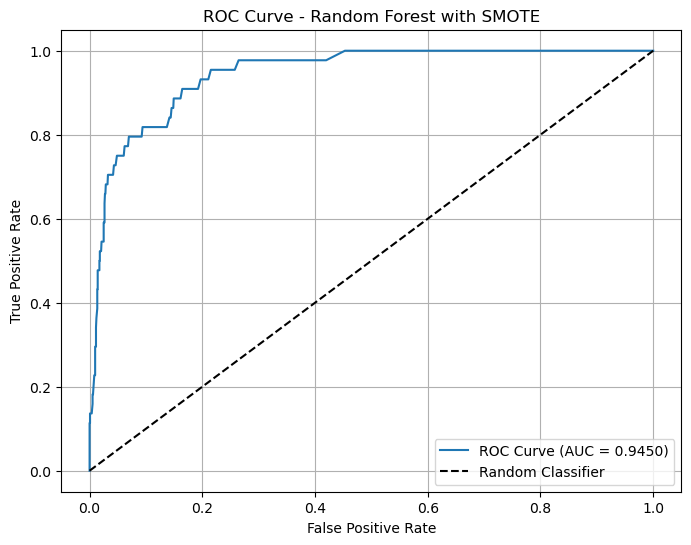

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve

# Calculate ROC-AUC Score
y_pred_proba = rf_smote.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest with SMOTE")
plt.legend()
plt.grid()
plt.show()

In [15]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

# Perform 5-Fold Cross-Validation
scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall_weighted': make_scorer(recall_score, average='weighted', zero_division=0),
    'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0)
}

cv_results = cross_validate(rf_smote, X_train_smote, y_train_smote, cv=5, scoring=scoring)

print("5-Fold Cross-Validation Results:")
print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"Precision: {cv_results['test_precision_weighted'].mean():.4f} (+/- {cv_results['test_precision_weighted'].std():.4f})")
print(f"Recall: {cv_results['test_recall_weighted'].mean():.4f} (+/- {cv_results['test_recall_weighted'].std():.4f})")
print(f"F1-Score: {cv_results['test_f1_weighted'].mean():.4f} (+/- {cv_results['test_f1_weighted'].std():.4f})")

5-Fold Cross-Validation Results:
Accuracy: 0.9803 (+/- 0.0032)
Precision: 0.9808 (+/- 0.0029)
Recall: 0.9803 (+/- 0.0032)
F1-Score: 0.9803 (+/- 0.0032)


Starting GridSearchCV for hyperparameter optimization...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-Validation F1-Score: 0.9778

Optimized Model Test Accuracy: 0.9611
Optimized Model Test F1-Score: 0.9642


In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_smote.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(15))

                                              Feature  Importance
9                Continuous interest rate (after tax)    0.058452
35                         Total debt/Total net worth    0.058276
18            Persistent EPS in the Last Four Seasons    0.050704
7                         After-tax net Interest Rate    0.049656
85                         Net Income to Total Assets    0.047730
67                  Retained Earnings to Total Assets    0.045263
39                               Borrowing dependency    0.041861
37                                   Net worth/Assets    0.029136
36                                       Debt ratio %    0.027604
89                 Net Income to Stockholder's Equity    0.026424
42              Net profit before tax/Paid-in capital    0.026243
90                                Liability to Equity    0.025259
6                           Pre-tax net Interest Rate    0.022314
2    ROA(B) before interest and depreciation after...    0.020753
22        

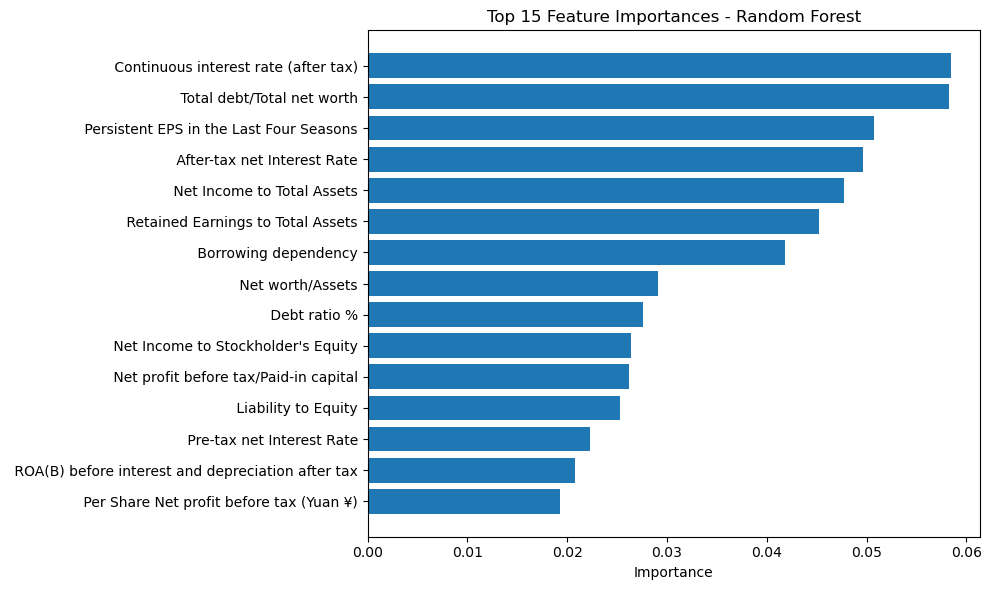

In [18]:
top15 = feature_importance.head(15).sort_values(by="Importance")
plt.figure(figsize=(10, 6))
plt.barh(top15["Feature"], top15["Importance"])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()